In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from itertools import product

In [2]:
df_fake = pd.read_csv('Fake.csv')

In [3]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
df_true = pd.read_csv('True.csv')

In [5]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
df_true['class'] = 0
df_fake['class'] = 1

In [7]:
df_fake.head()

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [8]:
df_true.head()

,title,text,subject,date,class
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [9]:
df = pd.concat([df_fake, df_true])

In [10]:
df

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1
...,...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",0
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",0
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",0
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",0


In [11]:
X = TfidfVectorizer(stop_words='english',
max_features=40).fit_transform(df['title'])

In [12]:
y = df.loc[:, df.columns == 'class'].values.ravel()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.98, random_state=14)

In [14]:
# Display OP
def annot(opi, _x, _y):
    plt.annotate(f"OP{opi}", xy=(_x, _y), xytext=(.90*_x+.1, .80*_y), arrowprops=dict(facecolor='lightgray', shrink=1))

In [15]:
classifiers = [
    ("Decision Tree",DecisionTreeClassifier,{"max_depth":[3, 6,9, 12], "max_features": [5, 10,15, 20]}),
    ("Random Forest",RandomForestClassifier,{"n_estimators":[30,50,70,100], "max_depth":[3, 6,12]}),
    ("Neural Network", MLPClassifier, {"hidden_layer_sizes":[(5,), (10,), (20,)],"learning_rate_init": [0.001,0.01, 0.1]})
]

[{'max_depth': 3, 'max_features': 5}, {'max_depth': 3, 'max_features': 10}, {'max_depth': 3, 'max_features': 15}, {'max_depth': 3, 'max_features': 20}, {'max_depth': 6, 'max_features': 5}, {'max_depth': 6, 'max_features': 10}, {'max_depth': 6, 'max_features': 15}, {'max_depth': 6, 'max_features': 20}, {'max_depth': 9, 'max_features': 5}, {'max_depth': 9, 'max_features': 10}, {'max_depth': 9, 'max_features': 15}, {'max_depth': 9, 'max_features': 20}, {'max_depth': 12, 'max_features': 5}, {'max_depth': 12, 'max_features': 10}, {'max_depth': 12, 'max_features': 15}, {'max_depth': 12, 'max_features': 20}]


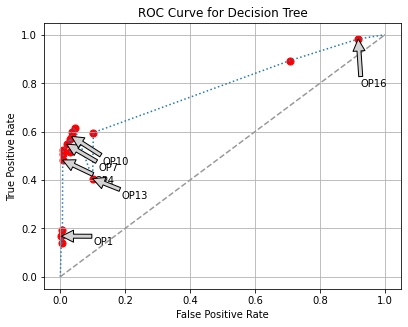

[{'n_estimators': 30, 'max_depth': 3}, {'n_estimators': 30, 'max_depth': 6}, {'n_estimators': 30, 'max_depth': 12}, {'n_estimators': 50, 'max_depth': 3}, {'n_estimators': 50, 'max_depth': 6}, {'n_estimators': 50, 'max_depth': 12}, {'n_estimators': 70, 'max_depth': 3}, {'n_estimators': 70, 'max_depth': 6}, {'n_estimators': 70, 'max_depth': 12}, {'n_estimators': 100, 'max_depth': 3}, {'n_estimators': 100, 'max_depth': 6}, {'n_estimators': 100, 'max_depth': 12}]


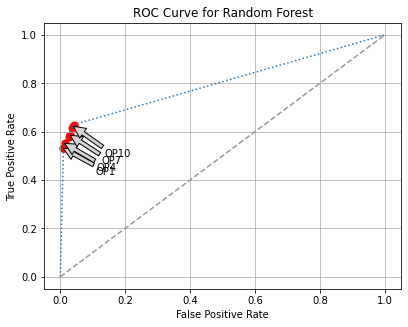

[{'hidden_layer_sizes': (5,), 'learning_rate_init': 0.001}, {'hidden_layer_sizes': (5,), 'learning_rate_init': 0.01}, {'hidden_layer_sizes': (5,), 'learning_rate_init': 0.1}, {'hidden_layer_sizes': (10,), 'learning_rate_init': 0.001}, {'hidden_layer_sizes': (10,), 'learning_rate_init': 0.01}, {'hidden_layer_sizes': (10,), 'learning_rate_init': 0.1}, {'hidden_layer_sizes': (20,), 'learning_rate_init': 0.001}, {'hidden_layer_sizes': (20,), 'learning_rate_init': 0.01}, {'hidden_layer_sizes': (20,), 'learning_rate_init': 0.1}]


/Users/sohumpohane/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sohumpohane/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sohumpohane/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sohumpohane/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimiza

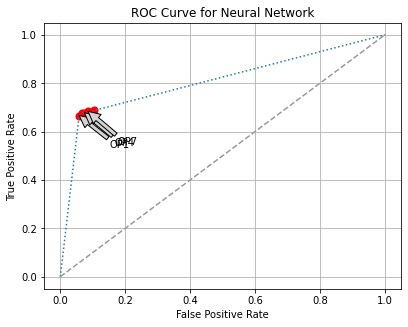

In [16]:
for name, clf_class, params in classifiers:
    FPR_list, TPR_list = [], []
    param_names = list(params.keys())
    param_combinations = [dict(zip(param_names, v)) for v in product(*params.values())]
    print(param_combinations)
    for param_set in param_combinations:
        clf = clf_class(**param_set, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        TPR_list.append(tp/(tp+fn))
        FPR_list.append(fp/ (fp+tn))
    
    FPR_list,TPR_list = zip(*sorted(zip(FPR_list, TPR_list)))
    fpr = [0.]+list(FPR_list)+[1.]
    tpr = [0.]+list(TPR_list)+[1.]
    fig, ax = plt.subplots(dpi=72)
    plt.plot(fpr, tpr, ':', label=f'{name} ROC Curve')
    plt.scatter(FPR_list, TPR_list, 50, color='red', marker='o')
    plt.plot([0, 1], [0, 1], linestyle='--', color=(0.6, 0.6, 0.6))
    for i,(fx, tx) in enumerate(zip(FPR_list, TPR_list)):
        if i%3 == 0:
            plt.annotate(f"OP{i+1}", xy=(fx, tx), xytext=(.90*fx+.1, .80*tx),arrowprops=dict(facecolor='lightgray', shrink=1))
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.grid()
    plt.title(f'ROC Curve for {name}')
    plt.show()


I expect to see a curve to be above the diagonal which represents a random guess. A curve above would mean it performs better than randomly guessing. I also expect that as PD increases, PF will also increase, because it will detect more false alarms. I also dont expect a smooth curve every time, but rather more diverse points.
I see these qualities in my plots. As seen above, the curves are all above the random guess line. We also see that generally as PD increases, PF increases as well. The curves are also not always that smooth as seen with the Random Forest ROC and Neural Network ROC.

When choosing the right classifier, I am looking for the classifier which gives the best AUC or hugs the top left corner the most. In that case, it looks like the neural netwok does this the best. While the graphs are all relatively close and all perform well, I will choose to go with the neural network. In terms of choosing the right operating point I want to choose the one which maximizes TPR primarily. This is because detecting less fake news could result in more harmful outcomes. It is best to detect as much fake news as possible, even though there are false alarms. Wrongly flagging something as real news as ake news is still important but not as important at getting all the fake news. Therefore I will pick the point which aximizes this True positive rate which means the right most operating point.

In [17]:
from scipy.sparse import hstack

In [18]:
Xtitle = TfidfVectorizer(stop_words='english',
max_features=40).fit_transform(df['title'])

In [19]:
Xtext = TfidfVectorizer(stop_words='english',
max_features=40).fit_transform(df['text'])

In [20]:
XRes = hstack([Xtitle, Xtext])

In [21]:
y = df.loc[:, df.columns == 'class'].values.ravel()

In [22]:
X_train, X_test, y_train, y_test = train_test_split(XRes, y, test_size=0.98, random_state=14)

In [23]:
classifiers = [
    ("Decision Tree",DecisionTreeClassifier,{"max_depth":[3, 6,9, 12], "max_features": [5, 10,15, 20]}),
    ("Random Forest",RandomForestClassifier,{"n_estimators":[30,50,70,100], "max_depth":[3, 6,12]}),
    ("Neural Network", MLPClassifier, {"hidden_layer_sizes":[(5,), (10,), (20,)],"learning_rate_init": [0.001,0.01, 0.1]})
]

[{'max_depth': 3, 'max_features': 5}, {'max_depth': 3, 'max_features': 10}, {'max_depth': 3, 'max_features': 15}, {'max_depth': 3, 'max_features': 20}, {'max_depth': 6, 'max_features': 5}, {'max_depth': 6, 'max_features': 10}, {'max_depth': 6, 'max_features': 15}, {'max_depth': 6, 'max_features': 20}, {'max_depth': 9, 'max_features': 5}, {'max_depth': 9, 'max_features': 10}, {'max_depth': 9, 'max_features': 15}, {'max_depth': 9, 'max_features': 20}, {'max_depth': 12, 'max_features': 5}, {'max_depth': 12, 'max_features': 10}, {'max_depth': 12, 'max_features': 15}, {'max_depth': 12, 'max_features': 20}]


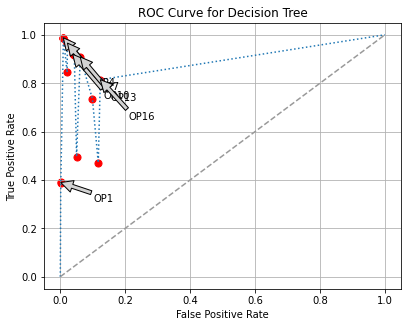

[{'n_estimators': 30, 'max_depth': 3}, {'n_estimators': 30, 'max_depth': 6}, {'n_estimators': 30, 'max_depth': 12}, {'n_estimators': 50, 'max_depth': 3}, {'n_estimators': 50, 'max_depth': 6}, {'n_estimators': 50, 'max_depth': 12}, {'n_estimators': 70, 'max_depth': 3}, {'n_estimators': 70, 'max_depth': 6}, {'n_estimators': 70, 'max_depth': 12}, {'n_estimators': 100, 'max_depth': 3}, {'n_estimators': 100, 'max_depth': 6}, {'n_estimators': 100, 'max_depth': 12}]


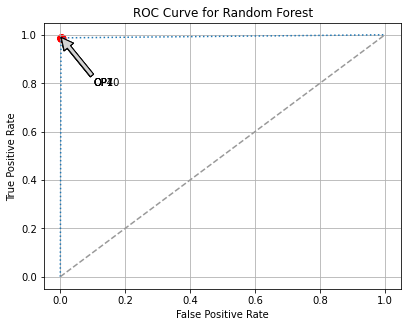

[{'hidden_layer_sizes': (5,), 'learning_rate_init': 0.001}, {'hidden_layer_sizes': (5,), 'learning_rate_init': 0.01}, {'hidden_layer_sizes': (5,), 'learning_rate_init': 0.1}, {'hidden_layer_sizes': (10,), 'learning_rate_init': 0.001}, {'hidden_layer_sizes': (10,), 'learning_rate_init': 0.01}, {'hidden_layer_sizes': (10,), 'learning_rate_init': 0.1}, {'hidden_layer_sizes': (20,), 'learning_rate_init': 0.001}, {'hidden_layer_sizes': (20,), 'learning_rate_init': 0.01}, {'hidden_layer_sizes': (20,), 'learning_rate_init': 0.1}]


/Users/sohumpohane/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sohumpohane/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sohumpohane/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sohumpohane/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimiza

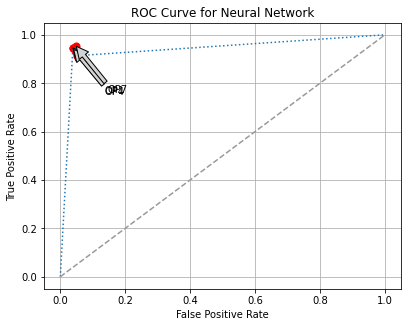

In [24]:
for name, clf_class, params in classifiers:
    FPR_list, TPR_list = [], []
    param_names = list(params.keys())
    param_combinations = [dict(zip(param_names, v)) for v in product(*params.values())]
    print(param_combinations)
    for param_set in param_combinations:
        clf = clf_class(**param_set, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        TPR_list.append(tp/(tp+fn))
        FPR_list.append(fp/ (fp+tn))
    
    FPR_list,TPR_list = zip(*sorted(zip(FPR_list, TPR_list)))
    fpr = [0.]+list(FPR_list)+[1.]
    tpr = [0.]+list(TPR_list)+[1.]
    fig, ax = plt.subplots(dpi=72)
    plt.plot(fpr, tpr, ':', label=f'{name} ROC Curve')
    plt.scatter(FPR_list, TPR_list, 50, color='red', marker='o')
    plt.plot([0, 1], [0, 1], linestyle='--', color=(0.6, 0.6, 0.6))
    for i,(fx, tx) in enumerate(zip(FPR_list, TPR_list)):
        if i%3 == 0:
            plt.annotate(f"OP{i+1}", xy=(fx, tx), xytext=(.90*fx+.1, .80*tx),arrowprops=dict(facecolor='lightgray', shrink=1))
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.grid()
    plt.title(f'ROC Curve for {name}')
    plt.show()


I tested this newly created dataset including text feature columns now in our input. As we can see, all the classifiers on general have a better performance. We can tell this because of the area under the curve of the ROC being greater for each respective classifier. The operating points are also closer to the top left which is higher TPR and lower FPR. The performance is much higher likely because the text column gives a lot of information about telling whether a certain article is fake news or real news including terms that are used in the text.